# Scientific Computing 1: Track Finding


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

## Sample of Space Points Simulation

In [2]:
class detector:
    """
    Detector consisting of a number of detection planes

    Attributes:
        planes: x coordinates of detection planes
        xRange: limits of axis x values. Array of form [minimum x value, maximum x value] 
        yRange: limits of axis y values. Array of form [minimum y value, maximum y value] 
        efficiency: probability that a hit will be detected
        type: detector type. Either 'Continuous' or 'Discrete'
        nDetectionElements: number of detection elements in which a plane is divided for the discrete case
        noise: probability of detecting extra hits
    """
    def __init__(self,nPlanes,planeRange,yRange,efficiency,type,nDetectionElements,noise):
        """
        Initializes a detector object

        Parameters:
            nPlanes: Number of planes
            planeRange: array of the form [initial plane x coordinate, final plane x coordinate]        
            yRange: array of the form [minimum y value, maximum y value]   
            efficiency: probability that a hit will be detected
            type: detector type. Either 'Continuous' or 'Discrete'
            nDetectionElements: number of detection elements in which a plane is divided for the discrete case
            noise: probability of detecting extra hits
        """

        #A message is displayed if the detector type is not correct
        if type!='Continuous' and type!='Discrete':
            print('Type argument must be \'Continuous\' or \'Discrete\' ')
            return
            
        self.planes=np.linspace(planeRange[0],planeRange[1],nPlanes) #Equal distance between planes is assumed   
        self.xRange=[0,self.planes[nPlanes-1]+self.planes[nPlanes-1]-self.planes[nPlanes-2]]
        self.yRange=yRange 
        self.efficiency=efficiency
        self.type=type
        self.nDetectionElements=nDetectionElements
        self.noise=noise

    def plot(self):
        """
        Plots the detector planes
        """
        #Plots planes of detection
        for i in range(len(self.planes)):
            plt.axvline(self.planes[i],color='Turquoise',zorder=1)

        #Axis format
        plt.axis([self.xRange[0],self.xRange[1],self.yRange[0],self.yRange[1]])
        plt.xlabel("x arbitrary coordinate")
        plt.ylabel("y arbitrary coordinate")
        plt.title(self.type+' detector. '+ 'Efficiency of '+str(self.efficiency*100)+'%'\
                 ' Noise of '+str(self.noise*100)+'%');
        
        plt.grid()

In [3]:
class spacePoints:
    """
    Generates a sample of space points in a given detector

    Attributes:
        nParticles: Number of particles
        mRange: limits for determining random m value in linear trajectory y=mx+b. Array of form [minimum m value, maximum m value]
        bRange: limits for determining random b value in linear trajectory y=mx+b. Array of form [minimum b value, maximum b value]
        detector: detector type object
        coordinates: numpy array of space points coordinates of the forms [x,y]      
    """
    
    def __init__(self,nParticles,mRange,bRange,detector):
        """
        Initializes a spacePoints object

        Parameters:
            nParticles: Number of particles
            mRange: array of the form [minimum m value, maximum m value]
            bRange: array of the form [minimum b value, maximum b value] 
            detector: detector type object    
        """
        self.nParticles=nParticles
        self.mRange=mRange
        self.bRange=bRange
        self.detector=detector

        #Depending on the type of detector a different function is used
        if self.detector.type=='Continuous': 
            self.coordinates=self.continuousSample()
            
        if self.detector.type=='Discrete':
            self.coordinates=self.discreteSample()

             
    def continuousSample(self):
        """
        Creates a sample of space points considering continuous detection planes
   
        Returns array of space points coordinates of the form [x,y]
        """
        #Generate a uniform random sample of N values for m and b for the N particle trajectories
        m=np.random.uniform(low=self.mRange[0], high=self.mRange[1], size=self.nParticles)
        b=np.random.uniform(low=self.bRange[0], high=self.bRange[1], size=self.nParticles)

        spacePoints=np.empty_like([0,0]) #A spacePoints array is initialized
        
        #Find intersections of each particle trajectory with each of the detection planes
        for i in range(len(self.detector.planes)):
            for j in range(self.nParticles):
                num=random.random() #Generates a random number

                #Record hit according to detector efficiency
                if num<self.detector.efficiency:
                    coordinate=np.array([self.detector.planes[i],m[j]*self.detector.planes[i]+b[j]]) #Evaluate trajectory on detection plane
                    spacePoints=np.vstack([spacePoints, coordinate])

                #Generate extra hit per each real hit according to detector noise
                if num<self.detector.noise:
                    x=self.detector.planes[i]
                    y=random.uniform(self.detector.yRange[0], self.detector.yRange[1])
                    coordinate=np.array([x,y])
                    spacePoints=np.vstack([spacePoints, coordinate])

        spacePoints=np.delete(spacePoints,0,0) #Eliminate initial arbitrary value

        return spacePoints

    def discreteSample(self):
        """
        Creates a sample of space points considering discrete detection planes. The hit is only measured 
        in the center of a detecting element 
        
        Returns array of space points coordinates of the form [x,y]
        """
        #Generate a uniform random sample of N values for m and b for the N particle trajectories
        m=np.random.uniform(low=self.mRange[0], high=self.mRange[1], size=self.nParticles)
        b=np.random.uniform(low=self.bRange[0], high=self.bRange[1], size=self.nParticles)

        #Discretization of detection planes
        yElements=np.linspace(self.detector.yRange[0],self.detector.yRange[1],self.detector.nDetectionElements+1) #limits of detection elements

        spacePoints=np.empty_like([0,0])#A spacePoints array is initialized

        #Find the intersections of each particle trajectory with the detection planes
        for i in range(len(self.detector.planes)):
            for j in range(self.nParticles):
                num=random.random() #Generates random number

                #Record hit according to detector efficiency
                if num<self.detector.efficiency:
                    coordinate=np.array([self.detector.planes[i],m[j]*self.detector.planes[i]+b[j]]) #Evaluate trajectory on detection plane

                    #Find in which detection element the y variable is and give a centered value to it
                    for k in range(len(yElements)):
                        if coordinate[1]>yElements[k] and coordinate[1]<yElements[k+1]:
                            coordinate[1]=(yElements[k]+yElements[k+1])/2
                    
                    spacePoints=np.vstack([spacePoints, coordinate])

                #Generate extra hit per each real hit according to detector noise
                if num<self.detector.noise:
                    x=self.detector.planes[i]
                    y=random.uniform(self.detector.yRange[0], self.detector.yRange[1])
                    coordinate=np.array([x,y])

                    #Find in which detection element the y variable is and give a centered value to it
                    for k in range(len(yElements)):
                        if coordinate[1]>yElements[k] and coordinate[1]<yElements[k+1]:
                            coordinate[1]=(yElements[k]+yElements[k+1])/2
                    
                    spacePoints=np.vstack([spacePoints, coordinate])

        spacePoints=np.delete(spacePoints,0,0) #Eliminate initial arbitrary value
   
        return spacePoints

    def plot(self):
        """ 
        Creates a plot for the space points
        """
        self.detector.plot() #Plot detector
        
        #Plot scatter of spacePoints
        plt.scatter(self.coordinates[:,0],self.coordinates[:,1],color='k',s=1,zorder=2)

        #Axis format
        plt.title(self.detector.type+' '+str(self.nParticles)+' particles Space Points. Efficiency of '+str(self.detector.efficiency*100)+'%'\
                 ' Noise of '+str(self.detector.noise*100)+'%');

## Track Finding Algorithm

In [4]:
class trackFinder:
    """
    Finds particle trajectories from a given set of space points

    Attributes:
        detector: detector type object
        spacePoints: spcePoints type object  
        dm: discretization of m domain
        nBins: number of divisions of the mb space for voting system
        threshold: threshold for voting system
        hLines: numpy array of Hough lines
        intersections: numpy array of intersection coordinates of the forms [x,y]
        dx: established discretization of x domain
        nParticlesDetected: number of detected particles from track finding algorithm
    """

    def __init__(self,detector,spacePoints,nBins,threshold):
        """
        Initializes a trackFinder object

        Parameters:
            detector: detector type object    
            spacePoints: spcePoints type object
            nBins: number of divisions of the mb space for voting system
            threshold: threshold for voting system
        """
        self.detector=detector
        self.spacePoints=spacePoints          
        self.dm=0.0001 #Established discretization of m domain
        self.hLines=self.HoughTransform() #Perform Hough transform
        self.intersections=self.realIntersections(nBins,threshold) #Decide valid Hough points with voting system
        self.dx=0.0001 #Established discretization of x domain

        #Determine number of particles from found trajectories. -99 represents that no trajectory was found
        if -99 in self.intersections:
            self.nParticlesDetected=0
        else:       
            self.nParticlesDetected=len(self.intersections)

               
    def intersect(self,A,B,C,D,xRange,yRange):
        """
        Finds intersection of line segments defined by AB and CD using a determinant method

        Parameters:
            A: defining point of line segmente. Array with form [x,y]
            B: defining point of line segmente. Array with form [x,y]
            C: defining point of line segmente. Array with form [x,y]
            D: defining point of line segmente. Array with form [x,y]
            xRange: limits of detector planes x values. Array of form [minimum x value, maximum x value] 
            yRange: limits of detector planes y values. Array of form [minimum y value, maximum y value]
           
        Returns the intersection point as [x,y]. Returns [-99,99] if no intersection is found.
        """
        a1=B[1]-A[1]
        b1=A[0]-B[0]
        c1=a1*A[0]+b1*A[1]

        a2=D[1]-C[1]
        b2=C[0]-D[0]
        c2=a2*C[0]+b2*C[1]

        determinant=a1*b2-a2*b1

        #If the determinant is 0 then no intersection is found along the domain
        if determinant==0:
            intersect=[-99,-99]

        else:
            intersect=np.array([(b2*c1 - b1*c2)/determinant,(a1*c2 - a2*c1)/determinant])

        #If the intersection is found outside the domain it is not counted
        if intersect[0]<xRange[0] or intersect[0]>xRange[1] or intersect[1]<yRange[0] or intersect[1]>yRange[1]:
            intersect=[-99,-99]
            
        return intersect
    
    def HoughTransform(self):
        """
        Performs Hough Transform for a given set of space points

        Parameters:
            mPoint: number of m discretization
            
        Returns numpy array of Hough lines
        """

        N=len(self.spacePoints.coordinates) #Number of points equal to number of Hough lines
        nM=int((self.spacePoints.mRange[1]-self.spacePoints.mRange[0])/self.dm)+1 #Number of linspace points
        m=np.linspace(self.spacePoints.mRange[0],self.spacePoints.mRange[1],nM) #Domain for m values
        hLines=np.zeros([N,len(m)]) #Array for N b=y-mx lines

        #Evaluate each Hough line
        for i in range(N):
            hLines[i]=self.spacePoints.coordinates[i,1]-m*self.spacePoints.coordinates[i,0]
    
        return hLines

    def realIntersections(self,nBins,threshold):
        """
        Finds and validates intersections in Hough transform with voting system.

        Parameters:
            nBins: number of divisions of the mb space
            threshold: threshold for voting system

        Returns numpy array of intersections of the form [m,b]. Returns a -99 2D array if no intersection is found.
        """
        N=len(self.hLines) #Number of Hough lines
        nM=int((self.spacePoints.mRange[1]-self.spacePoints.mRange[0])/self.dm)+1 #Number of linspace points
        m=np.linspace(self.spacePoints.mRange[0],self.spacePoints.mRange[1],nM) #Domain for m values

        intersections=np.empty_like([0,0]) #Initialize intersections array

        #Look for intersection of every line with every other line
        for i in range(N):
            for j in range(N):
                A=np.array([m[0],self.hLines[i,0]])
                B=np.array([m[len(m)-1],self.hLines[i,len(m)-1]])
                C=np.array([m[0],self.hLines[j,0]])
                D=np.array([m[len(m)-1],self.hLines[j,len(m)-1]])

                inter=self.intersect(A,B,C,D,self.spacePoints.mRange,self.spacePoints.bRange)

                if inter[0]!=-99: #If an intersection is found then it is added in the array
                    intersections=np.vstack([intersections, np.array(inter)])

        intersections=np.delete(intersections,0,0) #Eliminate initial arbitrary value
        
        #Bins count of m and b values
        countsM,binsM=np.histogram(intersections[:,0],bins=nBins)
        countsB,binsB=np.histogram(intersections[:,1],bins=nBins)

        #Voting system for bins with higher count than the threshold
        acceptedBinsM=np.empty_like([0,0]) 
        acceptedBinsB=np.empty_like([0,0]) 

        for i in range(len(countsM)):
            #If the count is higher than threshold, the corresponding bin is added in an array
            if countsM[i]>threshold:
                acceptedBinsM=np.vstack([acceptedBinsM,np.array([binsM[i],binsM[i+1]])])
            if countsB[i]>threshold:
                acceptedBinsB=np.vstack([acceptedBinsB,np.array([binsB[i],binsB[i+1]])])
        
        #Eliminate initial arbitrary value
        acceptedBinsM=np.delete(acceptedBinsM,0,0) 
        acceptedBinsB=np.delete(acceptedBinsB,0,0)

        #If no bin was accepted then an array of -99 is returned
        if np.shape(acceptedBinsM)[0]==1 or np.shape(acceptedBinsB)[0]==1:
            self.threshold=threshold
            return np.array([[-99,-99],[-99,-99]])
    
        #Filtrate intersections to only consider those within the accepted bins
        trueIntersections=np.empty_like([0,0])

        #Each intersection is revised if lies within a given bin
        for i in range(len(acceptedBinsB)):        
            for j in range(len(acceptedBinsM)):
                #As there will be multiple intersections with slight variation within a same bin, an average will be taken of these
                sumM=0
                sumB=0
                c=0 #Counter for the average calculation
                for h in range(len(intersections)):
                    if intersections[h,0]>=acceptedBinsM[j,0] and intersections[h,0]<=acceptedBinsM[j,1]\
                        and intersections[h,1]>=acceptedBinsB[i,0] and intersections[h,1]<=acceptedBinsB[i,1]:
                        sumM=sumM+intersections[h,0]
                        sumB=sumB+intersections[h,1]
                        c=c+1
                    
                #If c is different than 0 at least one intersection was found in the given bin
                if c!=0:
                    trueIntersections=np.vstack([trueIntersections, np.array([sumM/c, sumB/c])])
                    
        trueIntersections=np.delete(trueIntersections,0,0) #Eliminate initial arbitrary value    
        self.threshold=threshold #Set value of object attribute
        
        return trueIntersections

    def trajectories(self):
        """
        Calculates the particle trajectories

        Returns an array of y=mx+b lines. Returns a -99 2D array if no trajectory is found.
        """
        #If no intersection was found, then there are no trajectories
        if self.intersections[0,0]==-99:
            return np.array([[-99,-99],[-99,-99]])

        nX=int((self.detector.xRange[1]-self.detector.xRange[0])/self.dx)+1 #Number of linspace points        
        x=np.linspace(self.detector.xRange[0], self.detector.xRange[1], nX) #Domain for x 
        N=len(self.intersections) #Number of detected particles
        trajectories=np.zeros([N,len(x)]) 

        #Calculating trajectories with y=mx+b
        for i in range(N):
            trajectories[i]=self.intersections[i,0]*x+self.intersections[i,1]

        return trajectories

    def plotHough(self):
        """
        Creates a plot of the Hough lines and detected intersections
        """
        N=len(self.hLines) #Number of Hough lines
        nM=int((self.spacePoints.mRange[1]-self.spacePoints.mRange[0])/self.dm)+1 #Number of linspace points
        m=np.linspace(self.spacePoints.mRange[0],self.spacePoints.mRange[1],nM) #Domain for m values

        #Plot Hough lines
        for i in range (len(self.hLines)):
            plt.plot(m,self.hLines[i],color='k',linewidth=0.7)
        
        plt.scatter(self.intersections[:,0],self.intersections[:,1],facecolors='none',edgecolors='r',zorder=2)           
        plt.title(str(self.nParticlesDetected)+' Intersections, Threshold:'+str(self.threshold))

        #Axis format
        plt.axis([self.spacePoints.mRange[0],self.spacePoints.mRange[1],self.spacePoints.bRange[0],self.spacePoints.bRange[1]])
        plt.xlabel("m arbitrary coordinate")
        plt.ylabel("b arbitrary coordinate")

        plt.grid()
        plt.show()

    def plotTrajectories(self):
        """
        Creates a plot of the space points and calculated trajectories
        """
        #Plot space points
        self.spacePoints.plot()

        #If intersection array contains -99, then there are no trajectories
        if self.intersections[0,0]!=-99:
            nX=int((self.detector.xRange[1]-self.detector.xRange[0])/self.dx)+1 #Number of linspace points        
            x=np.linspace(self.detector.xRange[0], self.detector.xRange[1], nX) #Domain for x 
            N=len(self.intersections)
        
            #Plot the trajectories
            trajectories=self.trajectories()
            for i in range(N):
                plt.plot(x,trajectories[i],color='k',linewidth=0.7)

        #Axis format
        plt.axis([self.detector.xRange[0],self.detector.xRange[1],self.detector.yRange[0],self.detector.yRange[1]])
        plt.xlabel("x arbitrary coordinate")
        plt.ylabel("y arbitrary coordinate")
        plt.title('Particle trajectories: '+str(self.nParticlesDetected))
        plt.show()

## Performance Evaluation

### Single trials

Ideal scenario: Continuous detecting elements, no noise, 100% efficiency

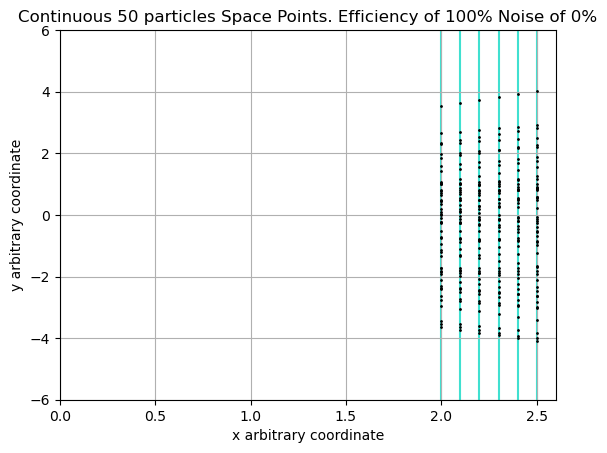

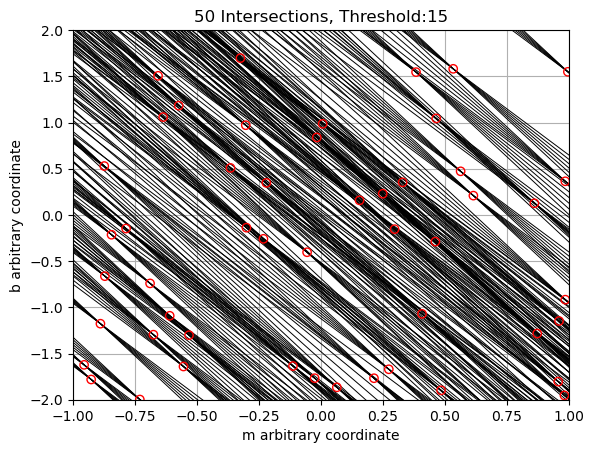

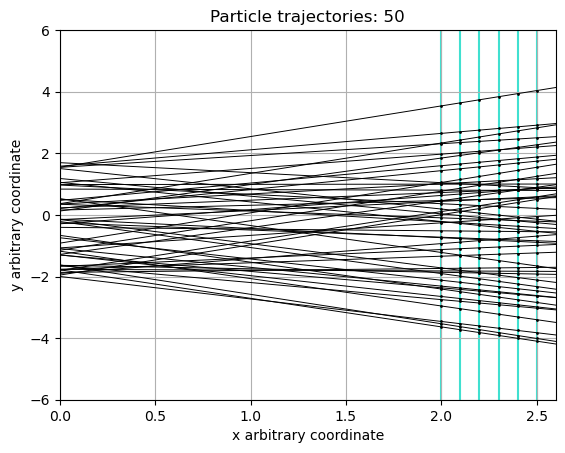

In [5]:
#Detector parameters
nPlanes=6
planeRange=[2,2.5]
yRange=[-6,6]
efficiency=1
nDetectionE=5000
type='Continuous' #'Discrete' or 'Continuous'
noise=0

detector1=detector(nPlanes,planeRange,yRange,efficiency,type,nDetectionE,noise)

#Space points parameters
nParticles=50
mRange=np.array([-1,1])
bRange=np.array([-2,2])

sample1=spacePoints(nParticles,mRange,bRange,detector1)

sample1.plot()
plt.show()

#Track finding parameters
nBins=5000
threshold=15
trackFinder1=trackFinder(detector1,sample1,nBins,threshold)
trackFinder1.plotHough()
trackFinder1.plotTrajectories()

Real scenario: Discrete detecting elements, 1% noise, 90% efficiency

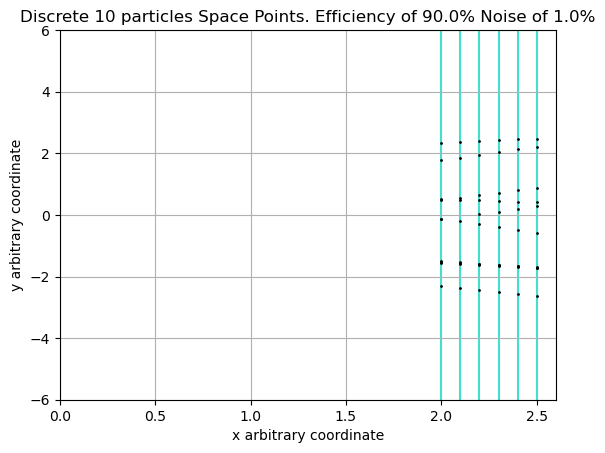

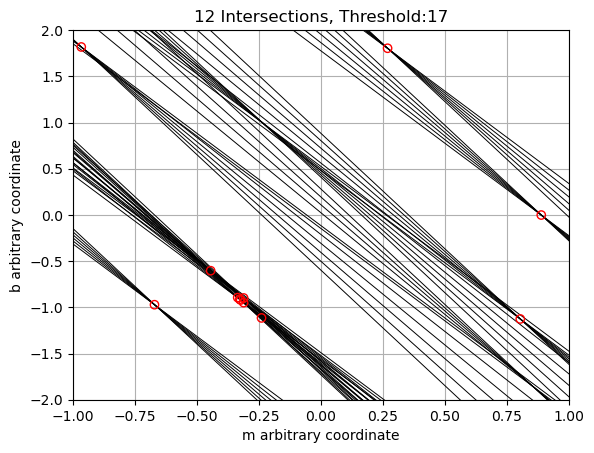

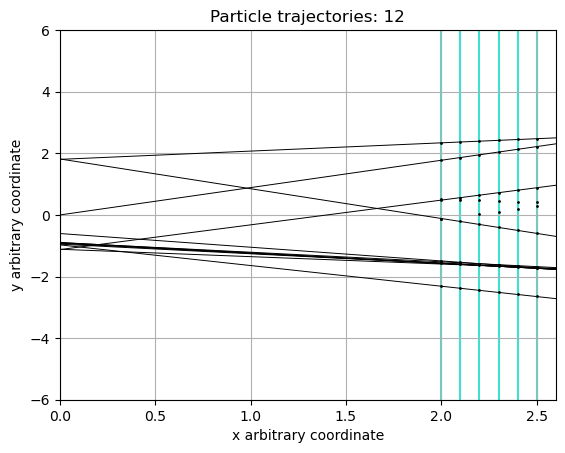

In [6]:
#Detector parameters
nPlanes=6
planeRange=[2,2.5]
yRange=[-6,6]
efficiency=0.9
nDetectionE=5000
type='Discrete' #'Discrete' or 'Continuous'
noise=0.01

detector2=detector(nPlanes,planeRange,yRange,efficiency,type,nDetectionE,noise)

#Space points parameters
nParticles=10
mRange=np.array([-1,1])
bRange=np.array([-2,2])

sample2=spacePoints(nParticles,mRange,bRange,detector2)

sample2.plot()
plt.show()

#Track finding parameters
nBins=100
threshold=17
trackFinder2=trackFinder(detector2,sample2,nBins,threshold)
trackFinder2.plotHough()
trackFinder2.plotTrajectories()

### Statistics

In [7]:
class stats:
    """
    Function to run statistical analysis of the trackfinding algorithm
    """
    def nParticlesVariance(detector,NP,mRange,bRange,nBins,threshold,N):
        """
        Statistical algorithm for doing multiple trials for different number of particles 

        Parameters:
            detector: detector type object    
            NP: number of particles array
            mRange: number of divisions of the mb space for voting system
            bRange: limits for determining random b value in linear trajectory y=mx+b. Array of form [minimum b value, maximum b value]
            nBins: number of divisions of the mb space for voting system
            threshold: threshold for voting system
            N: number of trials per number of particles

        Returns a numpy array of number of particles detected in each trial
        """
        nParticlesDetected=np.zeros([len(NP),N])

        #N trials for each number of particles value
        for j in range(len(NP)):
            for i in range(N):
                sample1=spacePoints(int(NP[j]),mRange,bRange,detector)
                trackFinder1=trackFinder(detector,sample1,nBins,threshold)
                nParticlesDetected[j,i]=trackFinder1.nParticlesDetected/NP[j] #Detected particles proportion is saved in an array
        return nParticlesDetected
        
    def thresholdVariance(detector,nParticles,mRange,bRange,nBins,TH,N):
        """
        Statistical algorithm for doing multiple trials for different thresholds

        Parameters:
            detector: detector type object    
            nParticles: number of particles 
            mRange: number of divisions of the mb space for voting system
            bRange: limits for determining random b value in linear trajectory y=mx+b. Array of form [minimum b value, maximum b value]
            nBins: number of divisions of the mb space for voting system
            TH: thresholds array
            N: number of trials per threshold

        Returns a numpy array of number of particles detected in each trial
        """
        nParticlesDetected=np.zeros([len(TH),N])

        #N trials for each threshold
        for j in range(len(TH)):
            for i in range(N):
                sample1=spacePoints(nParticles,mRange,bRange,detector)
                trackFinder1=trackFinder(detector,sample1,nBins,int(TH[j]))
                nParticlesDetected[j,i]=trackFinder1.nParticlesDetected/nParticles #Detected particles proportion is saved in an array
        return nParticlesDetected
    
    def nBinsVariance(detector,nParticles,mRange,bRange,NB,threshold,N):
        """
        Statistical algorithm for doing multiple trials for different number of bins

        Parameters:
            detector: detector type object    
            nParticles: number of particles 
            mRange: number of divisions of the mb space for voting system
            bRange: limits for determining random b value in linear trajectory y=mx+b. Array of form [minimum b value, maximum b value]
            NB: number of bins array
            threshold: threshold for voting system
            N: number of trials per threshold

        Returns a numpy array of number of particles detected in each trial
        """
        nParticlesDetected=np.zeros([len(NB),N])

        #N trials for each number of bins value
        for j in range(len(NB)):
            for i in range(N):
                sample1=spacePoints(nParticles,mRange,bRange,detector)
                trackFinder1=trackFinder(detector,sample1,int(NB[j]),threshold)
                nParticlesDetected[j,i]=trackFinder1.nParticlesDetected/nParticles #Detected particles proportion is saved in an array
        return nParticlesDetected

    def nDEVariance(nPlanes,planeRange,yRange,efficiency,type,ND,noise,nParticles,mRange,bRange,nBins,threshold,N):
        """
        Statistical algorithm for doing multiple trials for different number of detecting elements

        Parameters:
            nPlanes: Number of planes
            planeRange: array of the form [initial plane x coordinate, final plane x coordinate]        
            yRange: array of the form [minimum y value, maximum y value]   
            efficiency: probability that a hit will be detected
            type: detector type. Either 'Continuous' or 'Discrete'
            ND: number of detection elements array
            noise: probability of detecting extra hits 
            nParticles: number of particles 
            mRange: number of divisions of the mb space for voting system
            bRange: limits for determining random b value in linear trajectory y=mx+b. Array of form [minimum b value, maximum b value]
            nBins: number of bins array
            threshold: threshold for voting system
            N: number of trials per threshold

        Returns a numpy array of number of particles detected in each trial
        """
        nParticlesDetected=np.zeros([len(ND),N])

        #N trials for each number of detection elements value
        for j in range(len(ND)):
            detector1=detector(nPlanes,planeRange,yRange,efficiency,type,int(ND[j]),noise)
            for i in range(N):            
                sample1=spacePoints(nParticles,mRange,bRange,detector1)
                trackFinder1=trackFinder(detector1,sample1,nBins,threshold)
                nParticlesDetected[j,i]=trackFinder1.nParticlesDetected/nParticles #Detected particles proportion is saved in an array
        return nParticlesDetected

    def efVariance(nPlanes,planeRange,yRange,EF,type,nDetectionE,noise,nParticles,mRange,bRange,nBins,threshold,N):
        """
        Statistical algorithm for doing multiple trials for different number of detecting elements

        Parameters:
            nPlanes: Number of planes
            planeRange: array of the form [initial plane x coordinate, final plane x coordinate]        
            yRange: array of the form [minimum y value, maximum y value]   
            EF: efficiency array
            type: detector type. Either 'Continuous' or 'Discrete'
            nDetectionElements: number of detection elements in which a plane is divided for the discrete case
            noise: probability of detecting extra hits 
            nParticles: number of particles 
            mRange: number of divisions of the mb space for voting system
            bRange: limits for determining random b value in linear trajectory y=mx+b. Array of form [minimum b value, maximum b value]
            nBins: number of bins array
            threshold: threshold for voting system
            N: number of trials per threshold

        Returns a numpy array of number of particles detected in each trial
        """
        nParticlesDetected=np.zeros([len(EF),N])

        #N trials for each efficiency value
        for j in range(len(EF)):
            detector1=detector(nPlanes,planeRange,yRange,EF[j],type,nDetectionE,noise)
            for i in range(N):            
                sample1=spacePoints(nParticles,mRange,bRange,detector1)
                trackFinder1=trackFinder(detector1,sample1,nBins,threshold)
                nParticlesDetected[j,i]=trackFinder1.nParticlesDetected/nParticles #Detected particles proportion is saved in an array
        return nParticlesDetected

    def noVariance(nPlanes,planeRange,yRange,efficiency,type,nDetectionE,NO,nParticles,mRange,bRange,nBins,threshold,N):
        """
        Statistical algorithm for doing multiple trials for different number of detecting elements

        Parameters:
            nPlanes: Number of planes
            planeRange: array of the form [initial plane x coordinate, final plane x coordinate]        
            yRange: array of the form [minimum y value, maximum y value]   
            efficiency: probability that a hit will be detected
            type: detector type. Either 'Continuous' or 'Discrete'
            nDetectionElements: number of detection elements in which a plane is divided for the discrete case
            NO: noise values array 
            nParticles: number of particles 
            mRange: number of divisions of the mb space for voting system
            bRange: limits for determining random b value in linear trajectory y=mx+b. Array of form [minimum b value, maximum b value]
            nBins: number of bins array
            threshold: threshold for voting system
            N: number of trials per threshold

        Returns a numpy array of number of particles detected in each trial
        """
        nParticlesDetected=np.zeros([len(NO),N])

        #N trials for each noise value
        for j in range(len(NO)):
            detector1=detector(nPlanes,planeRange,yRange,efficiency,type,nDetectionE,NO[j])
            for i in range(N):            
                sample1=spacePoints(nParticles,mRange,bRange,detector1)
                trackFinder1=trackFinder(detector1,sample1,nBins,threshold)
                nParticlesDetected[j,i]=trackFinder1.nParticlesDetected/nParticles #Detected particles proportion is saved in an array
        return nParticlesDetected


    def plotMean(x,detectedParticles,variable):
        """
        Plot of the mean number of particles detected with a varying parameter

        Parameters:
            x: array of varying parameter
            detectedParticles: numpy array of number of particles detected in each trial
            variable: name of varying parameter
        """
        mean=np.mean(detectedParticles,axis=1)
        plt.scatter(x,mean);

        plt.xlabel(variable)
        plt.ylabel("Mean proportion of detected particles to true particles");
        plt.title(variable+' dependance');
        plt.grid();
        plt.show();

    def plotStd(x,detectedParticles,variable):
        """
        Plot of the standard deviation of particles detected with a varying parameter

        Parameters:
            x: array of varying parameter
            detectedParticles: numpy array of number of particles detected in each trial
            variable: name of varying parameter
        """
        std=np.std(detectedParticles,axis=1)
        plt.scatter(x,std);

        plt.xlabel(variable);
        plt.ylabel("Standard deviation of proportion");
        plt.title(variable+' dependance');
        plt.grid();
        plt.show();

#### Number of particles analysis

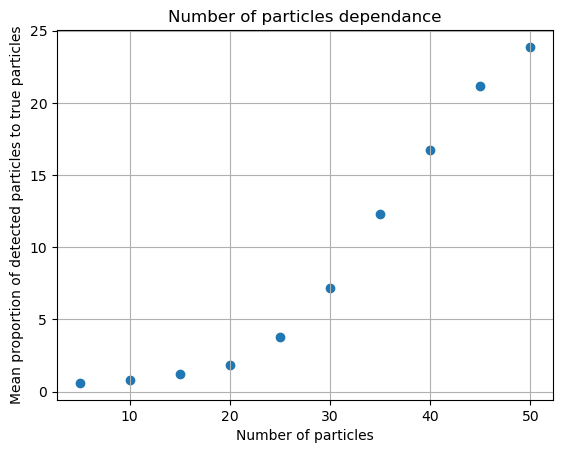

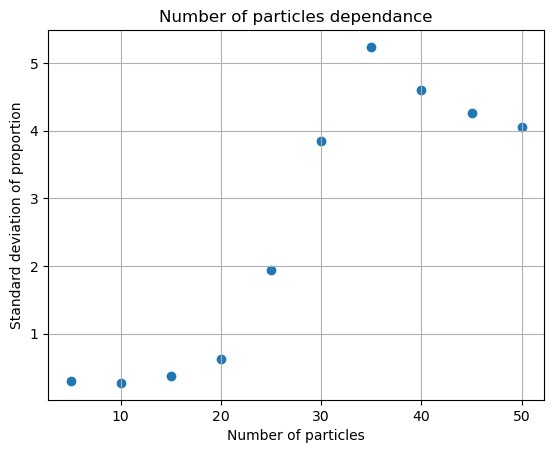

In [8]:
#Detector parameters
nPlanes=6
planeRange=[2,2.5]
yRange=[-6,6]
efficiency=0.9
nDetectionE=5000
type='Discrete' #'Discrete' or 'Continuous'
noise=0.01

detector1=detector(nPlanes,planeRange,yRange,efficiency,type,nDetectionE,noise)

#Space points parameters
mRange=np.array([-1,1])
bRange=np.array([-2,2])

N=100 #Number of trials for statistical analysis

#Track finding parameters
nBins=100
threshold=15

rangeZ=np.array([5,50])
dz=5
NP=np.linspace(rangeZ[0],rangeZ[1],int((rangeZ[1]-rangeZ[0])/dz)+1) #Number of particles to try
detectedParticlesNP=stats.nParticlesVariance(detector1,NP,mRange,bRange,nBins,threshold,N)
stats.plotMean(NP,detectedParticlesNP,'Number of particles')
stats.plotStd(NP,detectedParticlesNP,'Number of particles')

#### Threshold analysis

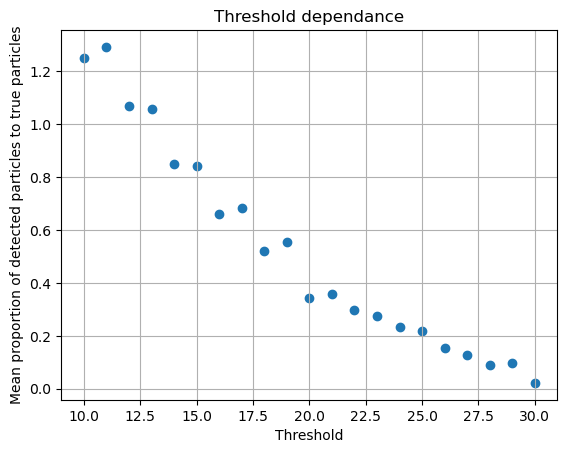

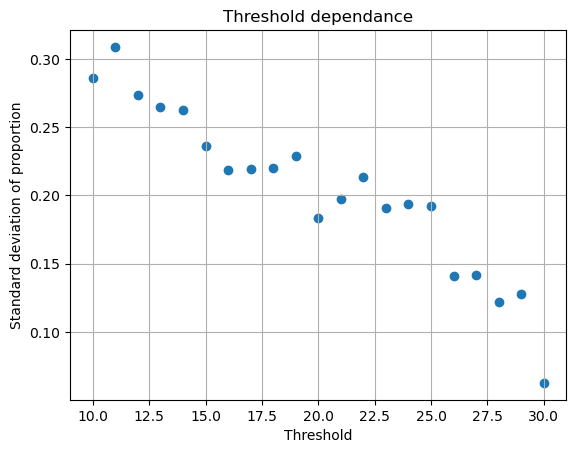

In [9]:
#Detector parameters
nPlanes=6
planeRange=[2,2.5]
yRange=[-6,6]
efficiency=0.9
nDetectionE=5000
type='Discrete' #'Discrete' or 'Continuous'
noise=0.01

detector1=detector(nPlanes,planeRange,yRange,efficiency,type,nDetectionE,noise)

#Space points parameters
mRange=np.array([-1,1])
bRange=np.array([-2,2])

N=100 #Number of trials for statistical analysis

#Track finding parameters
nParticles=10
nBins=100

rangeZ=np.array([10,30])
dz=1
TH=np.linspace(rangeZ[0],rangeZ[1],int((rangeZ[1]-rangeZ[0])/dz)+1)  #Thresholds to try
detectedParticlesTH=stats.thresholdVariance(detector1,nParticles,mRange,bRange,nBins,TH,N)
stats.plotMean(TH,detectedParticlesTH,'Threshold')
stats.plotStd(TH,detectedParticlesTH,'Threshold')

#### Number of Bins analysis

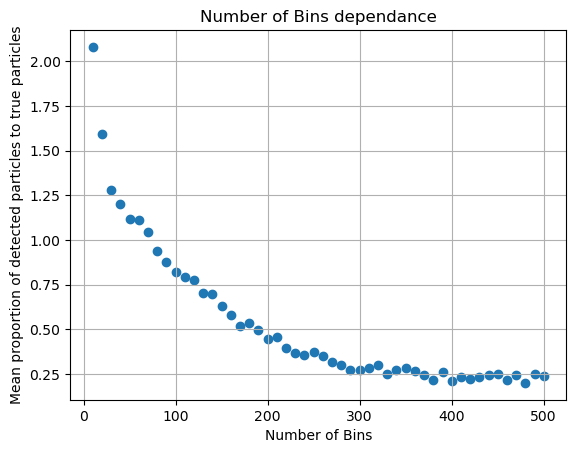

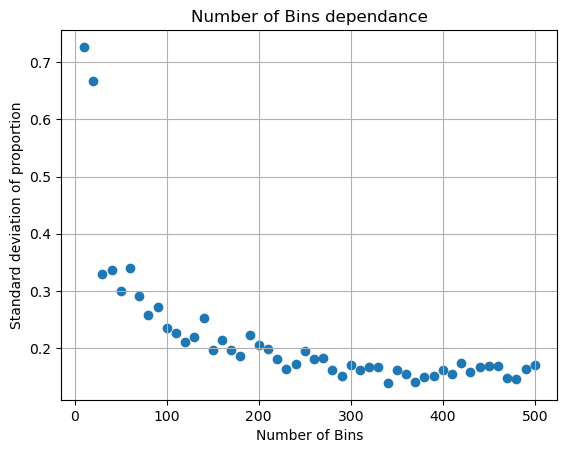

In [10]:
#Detector parameters
nPlanes=6
planeRange=[2,2.5]
yRange=[-6,6]
efficiency=0.9
nDetectionE=5000
type='Discrete' #'Discrete' or 'Continuous'
noise=0.01

detector1=detector(nPlanes,planeRange,yRange,efficiency,type,nDetectionE,noise)

#Space points parameters
mRange=np.array([-1,1])
bRange=np.array([-2,2])

N=100 #Number of trials for statistical analysis

#Track finding parameters
nParticles=10
threshold=15

rangeZ=np.array([10,500])
dz=10
NB=np.linspace(rangeZ[0],rangeZ[1],int((rangeZ[1]-rangeZ[0])/dz)+1)  #Number of bins to try
detectedParticlesNB=stats.nBinsVariance(detector1,nParticles,mRange,bRange,NB,threshold,N)
stats.plotMean(NB,detectedParticlesNB,'Number of Bins')
stats.plotStd(NB,detectedParticlesNB,'Number of Bins')

#### Detection Elements analysis

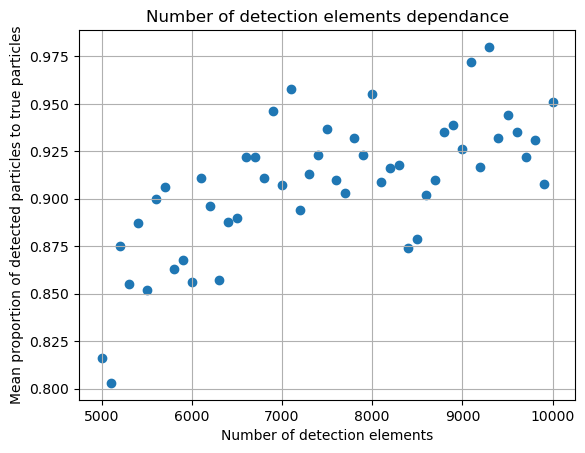

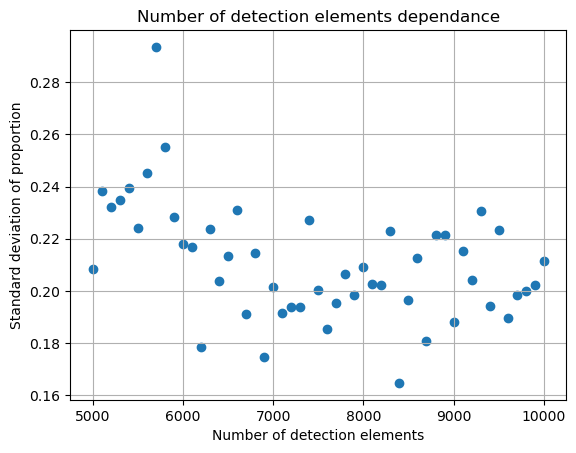

In [11]:
#Detector parameters
nPlanes=6
planeRange=[2,2.5]
yRange=[-6,6]
type='Discrete' #'Discrete' or 'Continuous'

#Space points parameters
mRange=np.array([-1,1])
bRange=np.array([-2,2])

N=100 #Number of trials for statistical analysis

nParticles=10
nBins=100
threshold=15

#Real scenario parameters
noise=0.01
efficiency=0.9

rangeZ=np.array([5000,10000])
dz=100
ND=np.linspace(rangeZ[0],rangeZ[1],int((rangeZ[1]-rangeZ[0])/dz)+1) #Number of detection elements to try
detectedParticlesND=stats.nDEVariance(nPlanes,planeRange,yRange,efficiency,type,ND,noise,nParticles,mRange,bRange,nBins,threshold,N)
stats.plotMean(ND,detectedParticlesND,'Number of detection elements')
stats.plotStd(ND,detectedParticlesND,'Number of detection elements')

#### Efficiency analysis

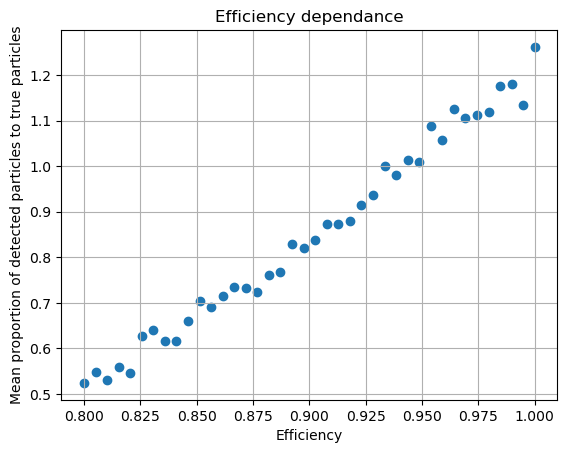

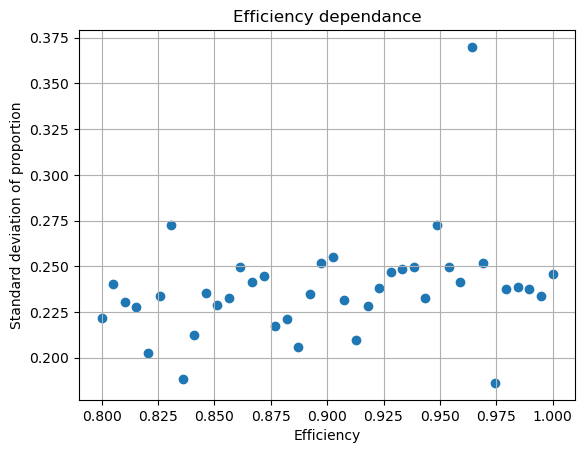

In [12]:
#Detector parameters
nPlanes=6
planeRange=[2,2.5]
yRange=[-6,6]
type='Discrete' #'Discrete' or 'Continuous'

#Space points parameters
mRange=np.array([-1,1])
bRange=np.array([-2,2])

N=100 #Number of trials for statistical analysis

#Real scenario parameters
nDetectionE=5000
noise=0.01

rangeZ=np.array([0.8,1])
dz=0.005
EF=np.linspace(rangeZ[0],rangeZ[1],int((rangeZ[1]-rangeZ[0])/dz)+1) #Number of detection elements to try
detectedParticlesEF=stats.efVariance(nPlanes,planeRange,yRange,EF,type,nDetectionE,noise,nParticles,mRange,bRange,nBins,threshold,N)
stats.plotMean(EF,detectedParticlesEF,'Efficiency')
stats.plotStd(EF,detectedParticlesEF,'Efficiency')

#### Noise analysis

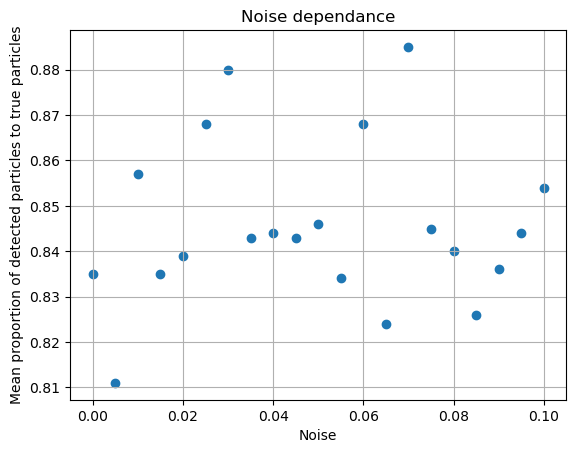

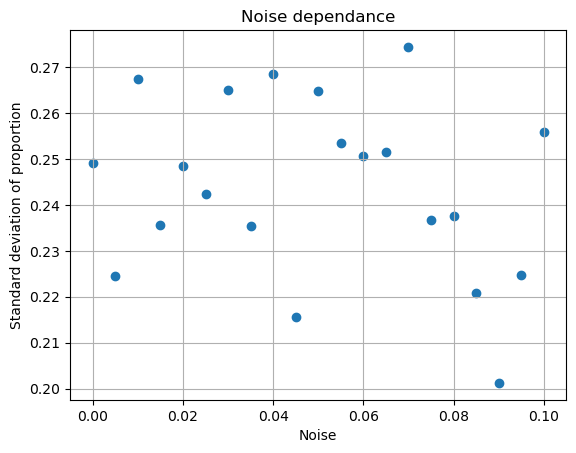

In [13]:
#Detector parameters
nPlanes=6
planeRange=[2,2.5]
yRange=[-6,6]
type='Discrete' #'Discrete' or 'Continuous'

#Space points parameters
mRange=np.array([-1,1])
bRange=np.array([-2,2])

N=100 #Number of trials for statistical analysis

#Real scenario parameters
nDetectionE=5000
efficiency=0.9

rangeZ=np.array([0,0.1])
dz=0.005
NO=np.linspace(rangeZ[0],rangeZ[1],int((rangeZ[1]-rangeZ[0])/dz)+1) #Number of detection elements to try
detectedParticlesNO=stats.noVariance(nPlanes,planeRange,yRange,efficiency,type,nDetectionE,NO,nParticles,mRange,bRange,nBins,threshold,N)
stats.plotMean(NO,detectedParticlesNO,'Noise')
stats.plotStd(NO,detectedParticlesNO,'Noise')